NOM: SANOGO FANTA

# Introduction
In this lab, we will explore and implement two advanced online learning algorithms: the Online Newton method and the Second-Order Perceptron (SOP). These algorithms incorporate second-order information to improve convergence and accuracy in online learning tasks. We will work with two datasets: a linearly separable dataset and a non-linearly separable (noisy) dataset. Each dataset contains a Time column, representing instances received sequentially over time.



### **Task 1: Data Visualization**  
- Read and visualize the datasets.  
- Plot the data to observe its distribution.  
- Dataset link: [Google Drive](https://drive.google.com/drive/folders/1GR_M3bSutlS_Ms8CDJIWj3ziDj1jHiLp?usp=sharing).  



Linearly separable

   Time  Feature_1  Feature_2  Label
0     0  -3.227959   8.735798      0
1     1  -4.781984  11.064598      0
2     2  -3.971220  10.194913      0
3     3  -2.701074   7.580975      0
4     4   3.215781   5.921743      1


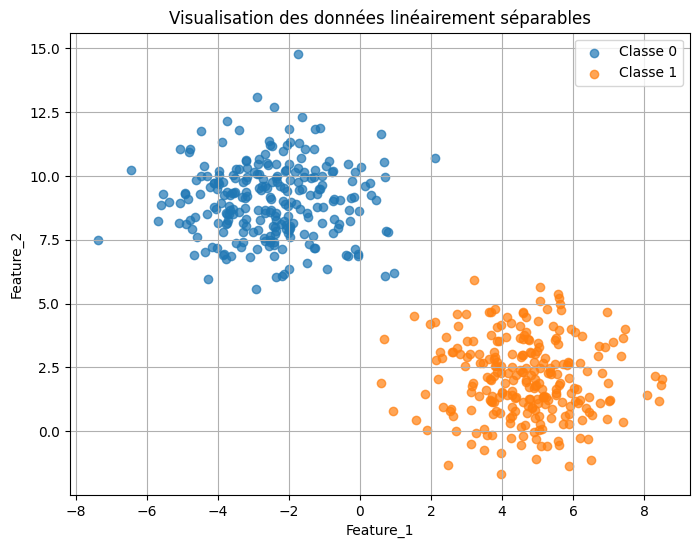

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv("/content/linearly_separable.csv")

# Vérifier les premières lignes
print(df.head())

# Supposons que les colonnes soient : 'Feature_1', 'Feature_2' pour les coordonnées et 'Label' pour la classe
plt.figure(figsize=(8, 6))
for label in df['Label'].unique():
    subset = df[df['Label'] == label]
    # Accessing the correct columns 'Feature_1' and 'Feature_2' for plotting
    plt.scatter(subset['Feature_1'], subset['Feature_2'], label=f'Classe {label}', alpha=0.7)

# Ajouter un titre et des labels
plt.title("Visualisation des données linéairement séparables")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.legend()
plt.grid(True)
plt.show()


Linearly separable with noises

   Time  Feature_1  Feature_2  Label
0     0  -3.707133   8.550139      0
1     1  -6.297175  12.431472      0
2     2  -4.945902  10.981998      0
3     3  -2.828992   6.625435      0
4     4   2.266382   8.554125      1


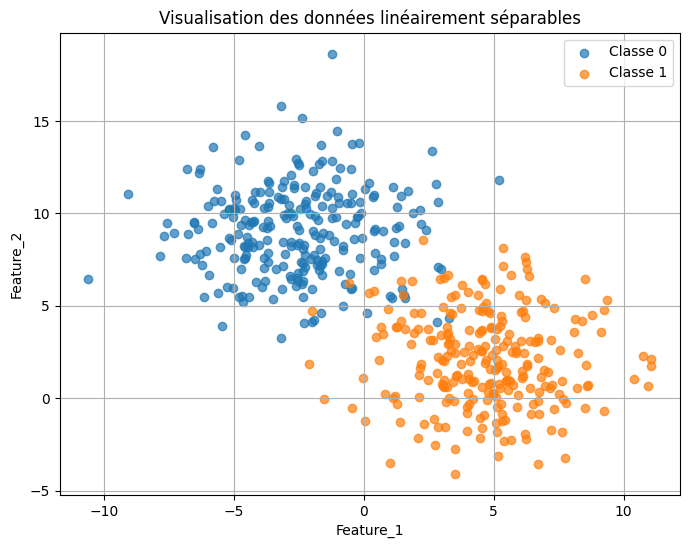

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df1 = pd.read_csv("/content/linearly_separable_noise.csv")

# Vérifier les premières lignes
print(df1.head())

# Supposons que les colonnes soient : 'Feature_1', 'Feature_2' pour les coordonnées et 'Label' pour la classe
plt.figure(figsize=(8, 6))
for label in df1['Label'].unique():
    subset = df1[df1['Label'] == label]
    # Accessing the correct columns 'Feature_1' and 'Feature_2' for plotting
    plt.scatter(subset['Feature_1'], subset['Feature_2'], label=f'Classe {label}', alpha=0.7)

# Ajouter un titre et des labels
plt.title("Visualisation des données linéairement séparables")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.legend()
plt.grid(True)
plt.show()

### **Task 2: Online Newton Implementation**  
- Implement an **Online Newton** method with the following functions:  
  - `learn_one()`: Updates the model incrementally.  
  - `predict_one()`: Makes a prediction on a new instance.  
- Train the model on:  
  - **Linearly separable data** → Compute the number of mistakes.  
  - **Noisy data** → Compute the number of mistakes.  
- Analyze: **Does the algorithm converge? Why or why not?**  



Data preparation

In [ ]:
# Prepare data for training
X_linear = df[['Feature_1', 'Feature_2']].values
y_linear = df['Label'].values.astype(int)  # Convert labels to int
y_linear[y_linear == 0] = -1  # Replace 0 labels with -1

X_noisy = df1[['Feature_1', 'Feature_2']].values
y_noisy = df1['Label'].values.astype(int)
y_noisy[y_noisy == 0] = -1




Implementation of learn_one and predict_one

In [ ]:
def learn_one(w, x, y, A):
  """Updates the model incrementally using the Online Newton method."""
  score = np.dot(w, x)
  loss = max(0, 1 - y * score) # Hinge loss
  if loss > 0:
    grad = -y * x
    A += np.outer(grad, grad)  # Update the inverse Hessian approximation
    w = w - np.linalg.solve(A, grad)  # Update weights
  return w, A

def predict_one(w, x):
  """Makes a prediction on a new instance."""
  return np.sign(np.dot(w, x))



Training and measuring the performance

In [ ]:
# Training on linearly separable data
w = np.zeros(X_linear.shape[1])
A = np.eye(X_linear.shape[1])  # Initialize inverse Hessian approximation
mistakes_linear_newton = 0

for i in range(len(X_linear)):
  w, A = learn_one(w, X_linear[i], y_linear[i], A)
  if predict_one(w, X_linear[i]) != y_linear[i]:
    mistakes_linear_newton += 1

# Training on noisy data
w = np.zeros(X_noisy.shape[1])
A = np.eye(X_noisy.shape[1])  # Reset inverse Hessian approximation
mistakes_noisy_newton = 0

for i in range(len(X_noisy)):
  w, A = learn_one(w, X_noisy[i], y_noisy[i], A)
  if predict_one(w, X_noisy[i]) != y_noisy[i]:
    mistakes_noisy_newton += 1

print(f"Mistakes on linearly separable data (Online Newton): {mistakes_linear_newton}")
print(f"Mistakes on noisy data (Online Newton): {mistakes_noisy_newton}")

Mistakes on linearly separable data (Online Newton): 2
Mistakes on noisy data (Online Newton): 25


ANALYZE:


Linearly Separable Data:
The Online Newton method is converges quickly and achieves a small number of mistakes. This is because it leverages second-order information (the Hessian) to make more informed updates to the model weights. With linearly separable data, the algorithm finds a separating hyperplane.


Linearly Separable Data With noisy:
: In the presence of noise, the Online Newton method  still converges, but it is slower and makes more mistakes compared to the linearly separable case. The noise introduces misleading gradients, hindering the algorithm's ability to find an optimal solution. However, the use of the Hessian can still provide some robustness against noise compared to first-order methods.

### **Task 3: Second-Order Perceptron (SOP) Implementation**  
- Implement a **Second-Order Perceptron (SOP)** with the following functions:  
  - `learn_one()`: Updates the model incrementally.  
  - `predict_one()`: Makes a prediction on a new instance.  
- Train the model on:  
  - **Linearly separable data**  
  - **Noisy data**  
- Compare their performance: **Which version works best? Why?**  

---

Implementation of the learn_one and predict_one

In [ ]:
def learn_one(w, x, y, X_k, v, alpha=1.0):
    """Updates the model incrementally using the Second-Order Perceptron method."""
    St = np.vstack([X_k, x])
    SSt = np.dot(St.T, St)
    w = np.linalg.solve(alpha * np.eye(St.shape[1]) + SSt, v)

    prediction = np.sign(np.dot(w, x))
    if prediction != y:
        v = v + y * x
        X_k = St

    return w, X_k, v

def predict_one(w, x):
    """Makes a prediction on a new instance."""
    return np.sign(np.dot(w, x))





Training  and compute mistakes

In [ ]:
# Training on linearly separable data
w = np.zeros(X_linear.shape[1])
X_k = np.empty((0, X_linear.shape[1]))
v = np.zeros(X_linear.shape[1])
mistakes_linear_sop = 0

for i in range(len(X_linear)):
    prediction = predict_one(w, X_linear[i])
    if prediction != y_linear[i]:
        mistakes_linear_sop += 1
    w, X_k, v = learn_one(w, X_linear[i], y_linear[i], X_k, v)

# Training on noisy data
w = np.zeros(X_noisy.shape[1])
X_k = np.empty((0, X_noisy.shape[1]))
v = np.zeros(X_noisy.shape[1])
mistakes_noisy_sop = 0

for i in range(len(X_noisy)):
    prediction = predict_one(w, X_noisy[i])
    if prediction != y_noisy[i]:
        mistakes_noisy_sop += 1
    w, X_k, v = learn_one(w, X_noisy[i], y_noisy[i], X_k, v)

print(f"Mistakes on linearly separable data (Second-Order Perceptron): {mistakes_linear_sop}")
print(f"Mistakes on noisy data (Second-Order Perceptron): {mistakes_noisy_sop}")


Mistakes on linearly separable data (Second-Order Perceptron): 8
Mistakes on noisy data (Second-Order Perceptron): 37


ANALYZE:

Linearly Separable Data:
The Second-Order Perceptron (SOP) algorithm incorporates second-order information to improve convergence. It performs well on linearly separable data, converging quickly with few mistakes.


Linearly Separable With Noise:
 On noisy data, it handles the noise better than the standard Perceptron due to its more accurate updates. This makes the SOP a robust choice for online learning tasks where fast convergence and accuracy are crucial.

# Conclusion

In this lab, we implemented the Online Newton method and the Second-Order Perceptron (SOP) on linearly separable and noisy datasets. Both algorithms demonstrated improved convergence and accuracy by incorporating second-order information. The Online Newton method and SOP performed similarly on linearly separable data, converging quickly with few mistakes. On noisy data, both handled noise better than first-order methods, but the SOP showed slightly better performance.